In [1]:
from utils import (
    load_cdf_files,
    plot_invalid_values,
    filter_valid_timesteps,
    merge_and_prepare_datasets,
    plot_variable_histograms,
    plot_dp_distributions,
    plot_correlation_heatmap,
    create_density_profile_filled,
    preprocess_train_valid_data,
    learnKappa_layers,
    modeltrain_loss,
    plot_training_validation_loss,
    plot_density_profile,
    performance_sigma_point,
)
import determine_mld

/Users/azamkhan/anaconda3/envs/nasa/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
dss = load_cdf_files("data")

In [3]:
dss.keys()

dict_keys(['temperature_profile', 'longwave_radiation', 'air_temperature', 'possition_lon_lat', 'shortwave_radiation', 'sea_surface_salinity', 'sea_surface_temperature', 'barometric_pressure', 'wind_speed_profile', 'rain', 'density_profile', 'salinity_profile'])

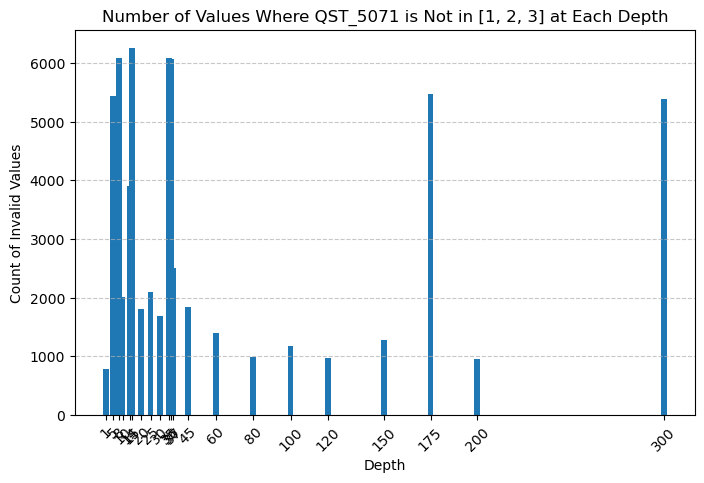

In [4]:
plot_invalid_values(
    dss,
    'density_profile',
    'QST_5071',
    [1,2,3]
)

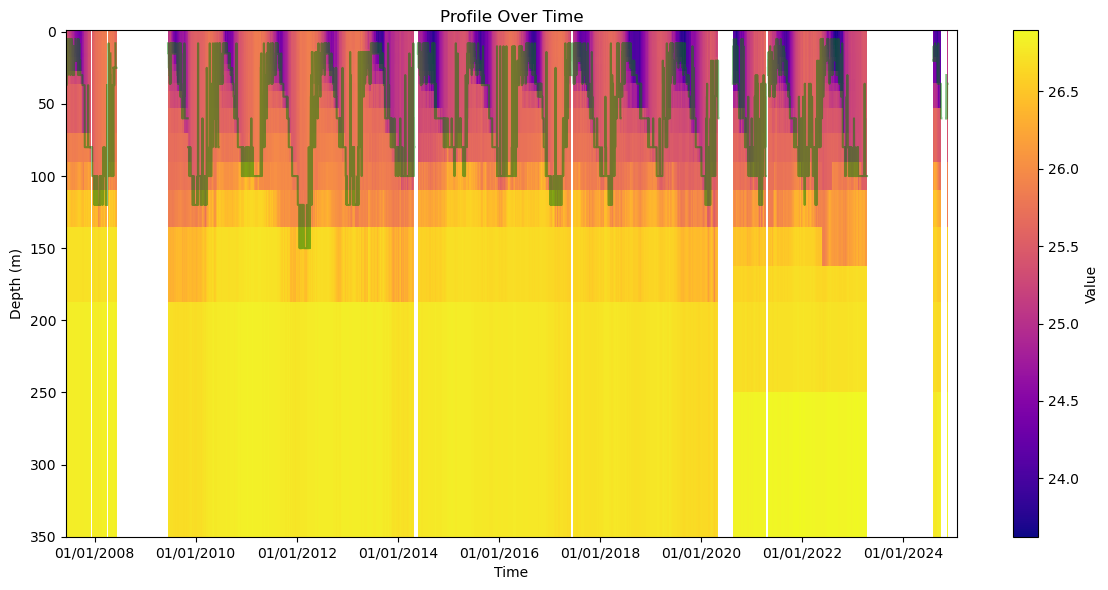

In [5]:
temp = filter_valid_timesteps(dss, "sea_surface_temperature", "QT_5025", "T_25")
sst = filter_valid_timesteps(dss, "sea_surface_salinity", "QS_5041", "S_41")
profiles, _ = determine_mld.plot_mld('density_papa')
filled_profiles = create_density_profile_filled(profiles, dss)

In [ ]:
full_df = merge_and_prepare_datasets(
    [(temp, ["time", "T_25"]), (sst, ["time", "S_41"])],
    filled_profiles,
    ["time"],
    ["time", "T_25", "S_41"],
)

In [31]:
full_df


,T_25,S_41,doy,DP_1,DP_2,DP_3,DP_4,DP_5,DP_6,DP_7,...,DP_12,DP_13,DP_14,DP_15,DP_16,DP_17,DP_18,DP_19,DP_20,DP_21
0,7.07,32.549000,159,25.480000,25.511000,25.507999,25.513000,25.513000,25.513000,25.513000,...,25.591000,25.591000,25.591000,25.833000,26.221001,26.566000,26.653999,26.653999,26.760000,26.760000
1,7.05,32.566002,160,25.495001,25.510000,25.507000,25.511000,25.511000,25.504999,25.509001,...,25.583000,25.583000,25.583000,25.829000,26.225000,26.568001,26.657000,26.657000,26.761000,26.761000
2,6.91,32.563999,161,25.513000,25.533001,25.528999,25.534000,25.534000,25.528000,25.528999,...,25.548000,25.548000,25.548000,25.806000,26.246000,26.566000,26.658001,26.658001,26.761000,26.761000
3,6.95,32.577000,162,25.518000,25.531000,25.527000,25.532000,25.532000,25.527000,25.528000,...,25.555000,25.555000,25.555000,25.806999,26.198000,26.570000,26.664000,26.664000,26.768999,26.768999
4,6.83,32.564999,163,25.524000,25.537001,25.533001,25.538000,25.538000,25.531000,25.534000,...,25.559999,25.559999,25.559999,25.799999,26.167999,26.577000,26.671000,26.671000,26.768000,26.768000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235,6.58,32.411999,99,25.436001,25.436001,25.443001,25.443001,25.443001,25.441000,25.441000,...,25.441999,25.441999,25.447001,25.448999,25.497999,26.190001,26.190001,26.684000,26.733999,26.882000
5236,6.54,32.415001,100,25.443001,25.443001,25.450001,25.450001,25.450001,25.448000,25.448000,...,25.448999,25.448999,25.452999,25.454000,25.510000,26.198000,26.198000,26.680000,26.731001,26.885000
5237,6.54,32.419998,101,25.448000,25.448000,25.455000,25.455000,25.455000,25.452999,25.452999,...,25.455000,25.455000,25.459000,25.459000,25.507999,26.221001,26.221001,26.686001,26.736000,26.882000
5238,6.53,32.410999,102,25.441000,25.441000,25.448000,25.448000,25.448000,25.448000,25.448000,...,25.452999,25.452999,25.459000,25.461000,25.513000,26.214001,26.214001,26.679001,26.731001,26.882000


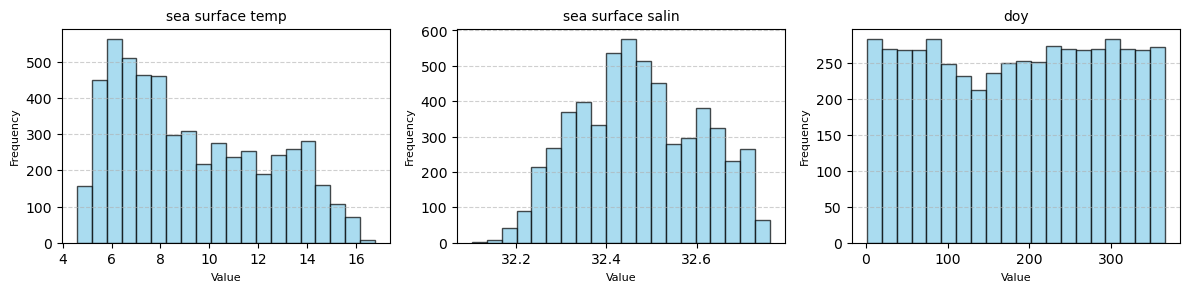

In [7]:
variables = {
    "sea surface temp": temp.values.flatten(),
    "sea surface salin": sst.values.flatten(),
    "doy": full_df["doy"].values.flatten(),
}

plot_variable_histograms(variables)

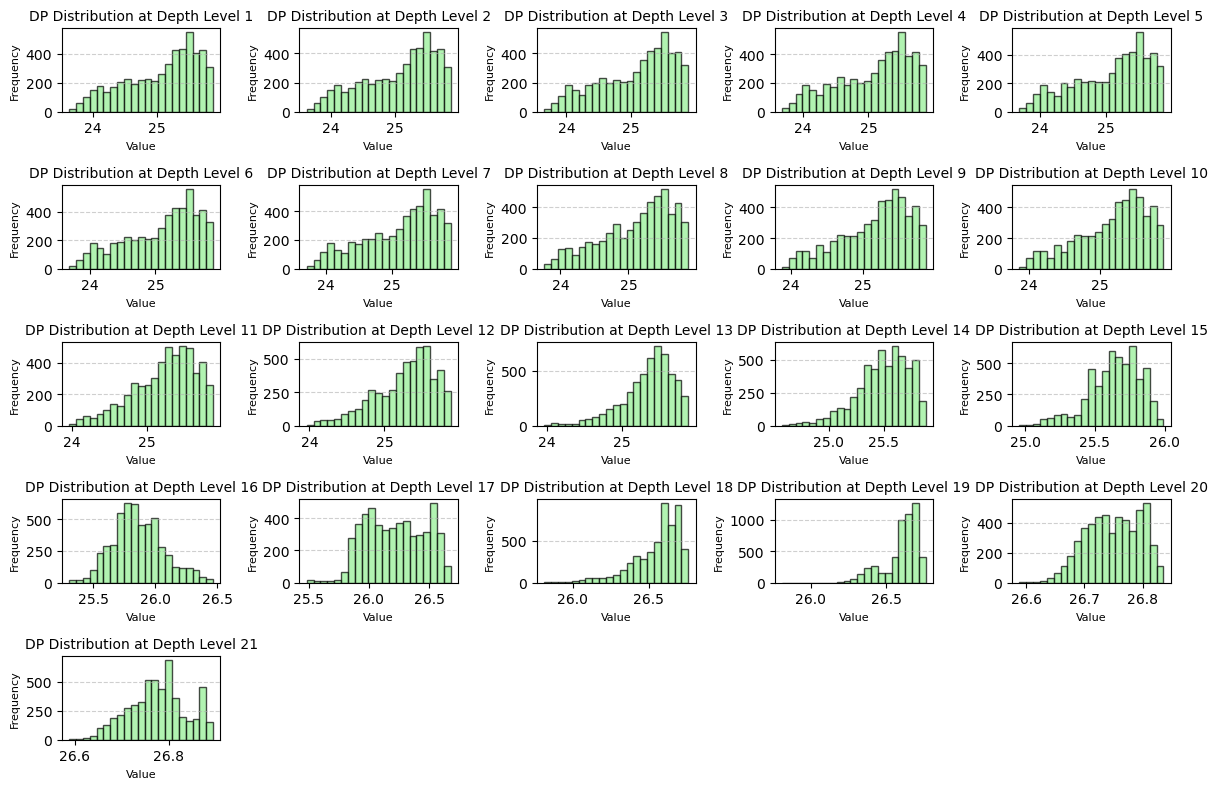

In [ ]:
plot_dp_distributions(
    full_df
)

In [9]:
full_df

,T_25,S_41,doy,DP_1,DP_2,DP_3,DP_4,DP_5,DP_6,DP_7,...,DP_12,DP_13,DP_14,DP_15,DP_16,DP_17,DP_18,DP_19,DP_20,DP_21
0,7.07,32.549000,159,25.480000,25.511000,25.507999,25.513000,25.513000,25.513000,25.513000,...,25.591000,25.591000,25.591000,25.833000,26.221001,26.566000,26.653999,26.653999,26.760000,26.760000
1,7.05,32.566002,160,25.495001,25.510000,25.507000,25.511000,25.511000,25.504999,25.509001,...,25.583000,25.583000,25.583000,25.829000,26.225000,26.568001,26.657000,26.657000,26.761000,26.761000
2,6.91,32.563999,161,25.513000,25.533001,25.528999,25.534000,25.534000,25.528000,25.528999,...,25.548000,25.548000,25.548000,25.806000,26.246000,26.566000,26.658001,26.658001,26.761000,26.761000
3,6.95,32.577000,162,25.518000,25.531000,25.527000,25.532000,25.532000,25.527000,25.528000,...,25.555000,25.555000,25.555000,25.806999,26.198000,26.570000,26.664000,26.664000,26.768999,26.768999
4,6.83,32.564999,163,25.524000,25.537001,25.533001,25.538000,25.538000,25.531000,25.534000,...,25.559999,25.559999,25.559999,25.799999,26.167999,26.577000,26.671000,26.671000,26.768000,26.768000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235,6.58,32.411999,99,25.436001,25.436001,25.443001,25.443001,25.443001,25.441000,25.441000,...,25.441999,25.441999,25.447001,25.448999,25.497999,26.190001,26.190001,26.684000,26.733999,26.882000
5236,6.54,32.415001,100,25.443001,25.443001,25.450001,25.450001,25.450001,25.448000,25.448000,...,25.448999,25.448999,25.452999,25.454000,25.510000,26.198000,26.198000,26.680000,26.731001,26.885000
5237,6.54,32.419998,101,25.448000,25.448000,25.455000,25.455000,25.455000,25.452999,25.452999,...,25.455000,25.455000,25.459000,25.459000,25.507999,26.221001,26.221001,26.686001,26.736000,26.882000
5238,6.53,32.410999,102,25.441000,25.441000,25.448000,25.448000,25.448000,25.448000,25.448000,...,25.452999,25.452999,25.459000,25.461000,25.513000,26.214001,26.214001,26.679001,26.731001,26.882000


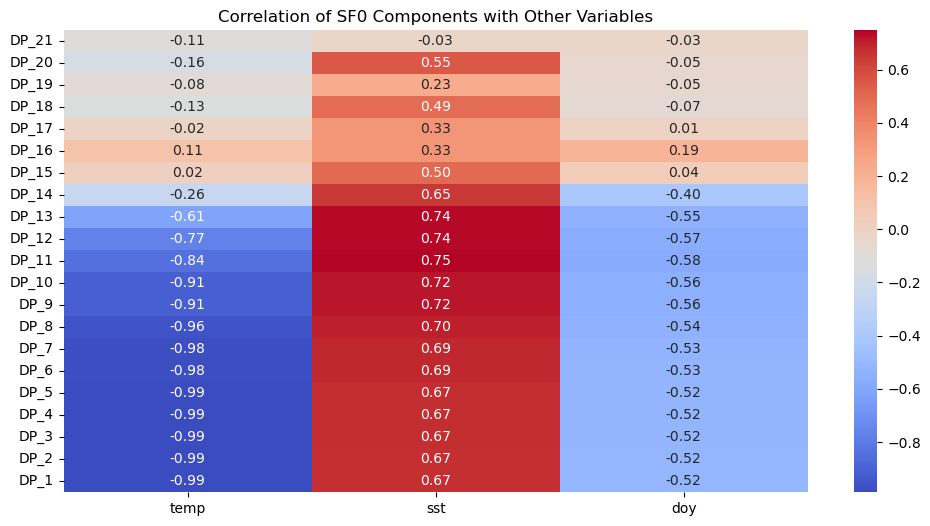

In [10]:
data = {

    "temp": full_df["T_25"].values.flatten(),
    "sst": full_df["S_41"].values.flatten(),
    "doy": full_df["doy"].values.flatten(),
}

plot_correlation_heatmap(
    full_df, data
)

In [11]:
import matplotlib.pyplot as plt
import copy as copy
import matplotlib as mpl

# import netCDF4 as ncd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import torch.utils.data as Data
from torch import nn, optim
import matplotlib.cm as cm
import copy as copy
import multiprocessing as mp
from scipy import stats
import time as time
import matplotlib.font_manager
import seaborn as sns
import pandas as pd
from tqdm import tqdm  # Import tqdm for the progress bar
import xarray as xr
import requests
import os
import numpy as np
import pandas as pd
from datetime import datetime
import warnings


In [12]:
mm1 = 0
mm2 = 21

# Iterate over each row in the DataFrame
dp_arrays = []
for _, row in full_df.iterrows():
    result = row[[f"DP_{x}" for x in range(21, 0, -1)]].values.flatten()[mm1:mm2]
    dp_arrays.append(result)

# Convert the list of arrays to a NumPy array
dp_array = np.array(dp_arrays)


In [13]:
mm1 = 0
mm2 = 21  # 0; 21
data_load_main = np.zeros([len(full_df), 3 + mm2 - mm1])
# data_load_main[:,0]=full_df['WS_401'].values.flatten()
data_load_main[:, 0] = full_df["T_25"].values.flatten()
data_load_main[:, 1] = full_df["S_41"].values.flatten()
data_load_main[:, 2] = full_df["doy"].values.flatten()
data_load_main[:, 3 : (mm2 - mm1 + 3)] = dp_array


In [14]:
import copy as copy

data_load3 = copy.deepcopy(data_load_main)

data, x, y, stats, k_mean, k_std, valid_x, valid_y, maxes = preprocess_train_valid_data(
    data_load3
)


In [24]:
data_load_main

array([[  7.07000017,  32.54899979, 159.        , ...,  25.50799942,
         25.51099968,  25.47999954],
       [  7.05000019,  32.56600189, 160.        , ...,  25.50699997,
         25.51000023,  25.49500084],
       [  6.90999985,  32.56399918, 161.        , ...,  25.52899933,
         25.53300095,  25.51300049],
       ...,
       [  6.53999996,  32.41999817, 101.        , ...,  25.45499992,
         25.44799995,  25.44799995],
       [  6.53000021,  32.4109993 , 102.        , ...,  25.44799995,
         25.44099998,  25.44099998],
       [ 13.17000008,  32.2140007 , 197.        , ...,  24.20199966,
         24.20199966,  24.20199966]])

In [27]:
full_df.describe()

,T_25,S_41,doy,DP_1,DP_2,DP_3,DP_4,DP_5,DP_6,DP_7,...,DP_12,DP_13,DP_14,DP_15,DP_16,DP_17,DP_18,DP_19,DP_20,DP_21
count,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,...,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000,5240.000000
mean,9.225223,32.483833,184.437023,25.064793,25.066067,25.072781,25.074314,25.077925,25.088427,25.097248,...,25.269329,25.350391,25.493994,25.642439,25.863848,26.215136,26.552427,26.599197,26.749582,26.777676
std,3.042938,0.130031,107.252040,0.564683,0.564024,0.559973,0.559094,0.557388,0.549962,0.541440,...,0.394902,0.338626,0.237002,0.180909,0.206980,0.245218,0.157978,0.115573,0.046117,0.060177
min,4.580000,32.102001,1.000000,23.622000,23.622000,23.658001,23.674999,23.683001,23.683001,23.707001,...,23.962999,23.962999,24.570000,24.958000,25.305000,25.483999,25.811001,25.811001,26.587999,26.587999
25%,6.560000,32.388000,88.000000,24.627750,24.629999,24.643999,24.650999,24.656000,24.682750,24.704000,...,25.009750,25.177000,25.353750,25.533001,25.730000,26.009001,26.476999,26.566999,26.714001,26.738001
50%,8.450000,32.474998,188.000000,25.223000,25.224001,25.229000,25.229000,25.232000,25.236500,25.238501,...,25.351000,25.417500,25.523001,25.660999,25.841000,26.212999,26.599001,26.632999,26.752001,26.778999
75%,11.680000,32.590000,278.000000,25.526249,25.528000,25.528999,25.531000,25.532000,25.532250,25.534000,...,25.559999,25.586000,25.670000,25.778000,25.990000,26.431999,26.671250,26.680000,26.790001,26.813000
max,16.469999,32.763000,366.000000,25.879999,25.879999,25.879999,25.879999,25.882000,25.882000,25.882000,...,25.882999,25.885000,25.885000,25.992001,26.468000,26.677999,26.760000,26.760000,26.836000,26.895000


In [25]:
stats

array([9.25347090e+00, 3.05123703e+00, 3.25132138e+01, 1.22908503e-01,
       1.86242366e+02, 1.06191481e+02])

In [20]:
import numpy as np


def prepare_data_pipeline(full_df, variables, dp_config=None):
    """
    Flexible data preparation pipeline that allows user to specify variables

    Args:
        full_df: Input DataFrame
        variables: List of dictionaries specifying variables to include in order
            Each dict should have:
            - 'name': column name in DataFrame
            - 'type': 'static' (single column) or 'dp' (DP array)
            For DP arrays, can optionally specify:
            - 'mm1': start index (default 0)
            - 'mm2': end index (default 21)
            - 'reverse': whether to reverse DP order (default True)
        dp_config: Optional global DP configuration (if not specified in individual variables)
            - 'mm1': default start index (default 0)
            - 'mm2': default end index (default 21)
            - 'reverse': default reverse flag (default True)

    Returns:
        numpy array of combined data
    """
    if dp_config is None:
        dp_config = {"mm1": 0, "mm2": 21, "reverse": True}

    # Process each variable and collect data chunks
    data_chunks = []
    total_columns = 0

    for var in variables:
        if var["type"] == "static":
            # Single column variable
            data = full_df[var["name"]].values.reshape(-1, 1)
            data_chunks.append(data)
            total_columns += 1
        elif var["type"] == "dp":
            # DP array variable
            mm1 = var.get("mm1", dp_config["mm1"])
            mm2 = var.get("mm2", dp_config["mm2"])
            reverse = var.get("reverse", dp_config["reverse"])

            dp_arrays = []
            for _, row in full_df.iterrows():
                dp_range = (
                    range(int(var["name"].split("_")[-1]), 0, -1)
                    if reverse
                    else range(1, int(var["name"].split("_")[-1]) + 1)
                )
                result = row[
                    [f"{var['name'].split('_')[0]}_{x}" for x in dp_range]
                ].values.flatten()[mm1:mm2]
                dp_arrays.append(result)

            dp_array = np.array(dp_arrays)
            data_chunks.append(dp_array)
            total_columns += mm2 - mm1

    # Combine all data chunks
    if not data_chunks:
        return np.empty((len(full_df), 0))

    data_load_main = np.hstack(data_chunks)
    return data_load_main


In [21]:
variables = [
    {"name": "T_25", "type": "static"},
    {"name": "S_41", "type": "static"},
    {"name": "doy", "type": "static"},
    {"name": "DP_21", "type": "dp"},  # Will use default DP config
]

dataDSFGD = prepare_data_pipeline(full_df, variables)

In [15]:
print("Training Set Size:", len(x))
print("Validation Set Size:", len(valid_x))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Convert to PyTorch tensors and move to device
x = torch.tensor(x, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.float32).to(device)
valid_x = torch.tensor(valid_x, dtype=torch.float32).to(device)
valid_y = torch.tensor(valid_y, dtype=torch.float32).to(device)


Training Set Size: 4192
Validation Set Size: 1048


In [16]:
# Train N1 for the first time!
epochs, k_points, lr = 5000, 21, 1e-02
in_nod, hid_nod, o_nod = 3, 32, 21

torch.manual_seed(10)

k_mean_c = torch.tensor(k_mean).float().to(device)
k_std_c = torch.tensor(k_std).float().to(device)

model = learnKappa_layers(in_nod, hid_nod, o_nod)
model = model.to(device)
model, loss_array = modeltrain_loss(
    in_nod,
    hid_nod,
    o_nod,
    lr,
    epochs,
    x,
    y,
    valid_x,
    valid_y,
    model,
    device,
    k_mean_c,
    k_std_c,
    patience=1000,
)

### in this version, there is no weighting in the loss function. This will be added in section 6.


Training Progress:  29%|██▉       | 1445/5000 [00:10<00:25, 140.13epoch/s, patience_count=999, train_loss=0.00321, valid_loss=0.00608]


Early stopping at epoch 1445. Validation loss has not improved for 1000 epochs.


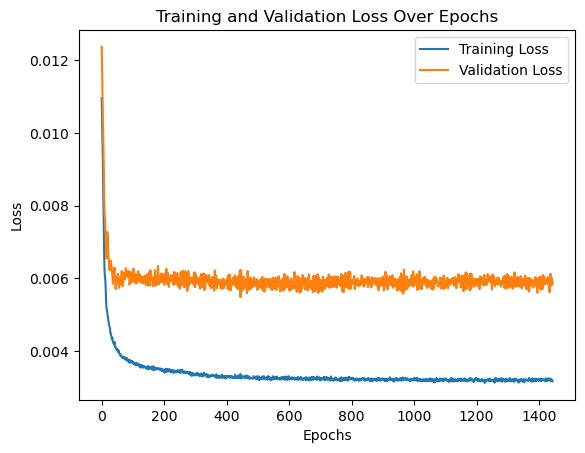

In [17]:
plot_training_validation_loss(loss_array)

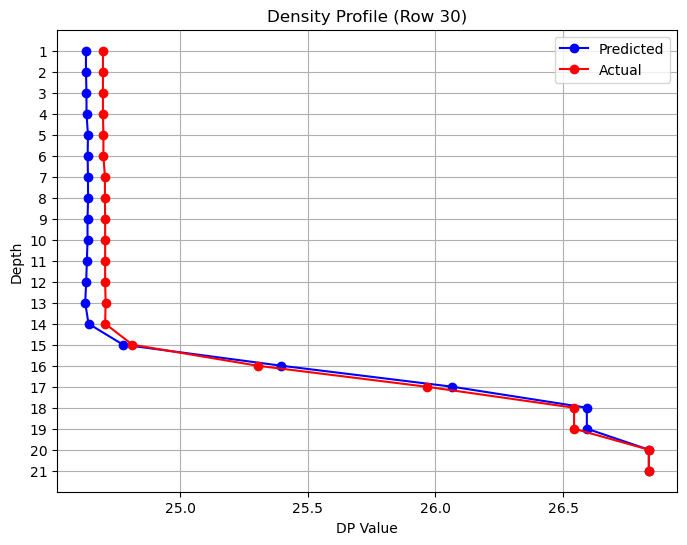

In [18]:
plot_density_profile(
    30,
    model(valid_x[30]).detach().numpy(),
    valid_y[30].detach().numpy(),
    k_std,
    k_mean,
    maxes,
)

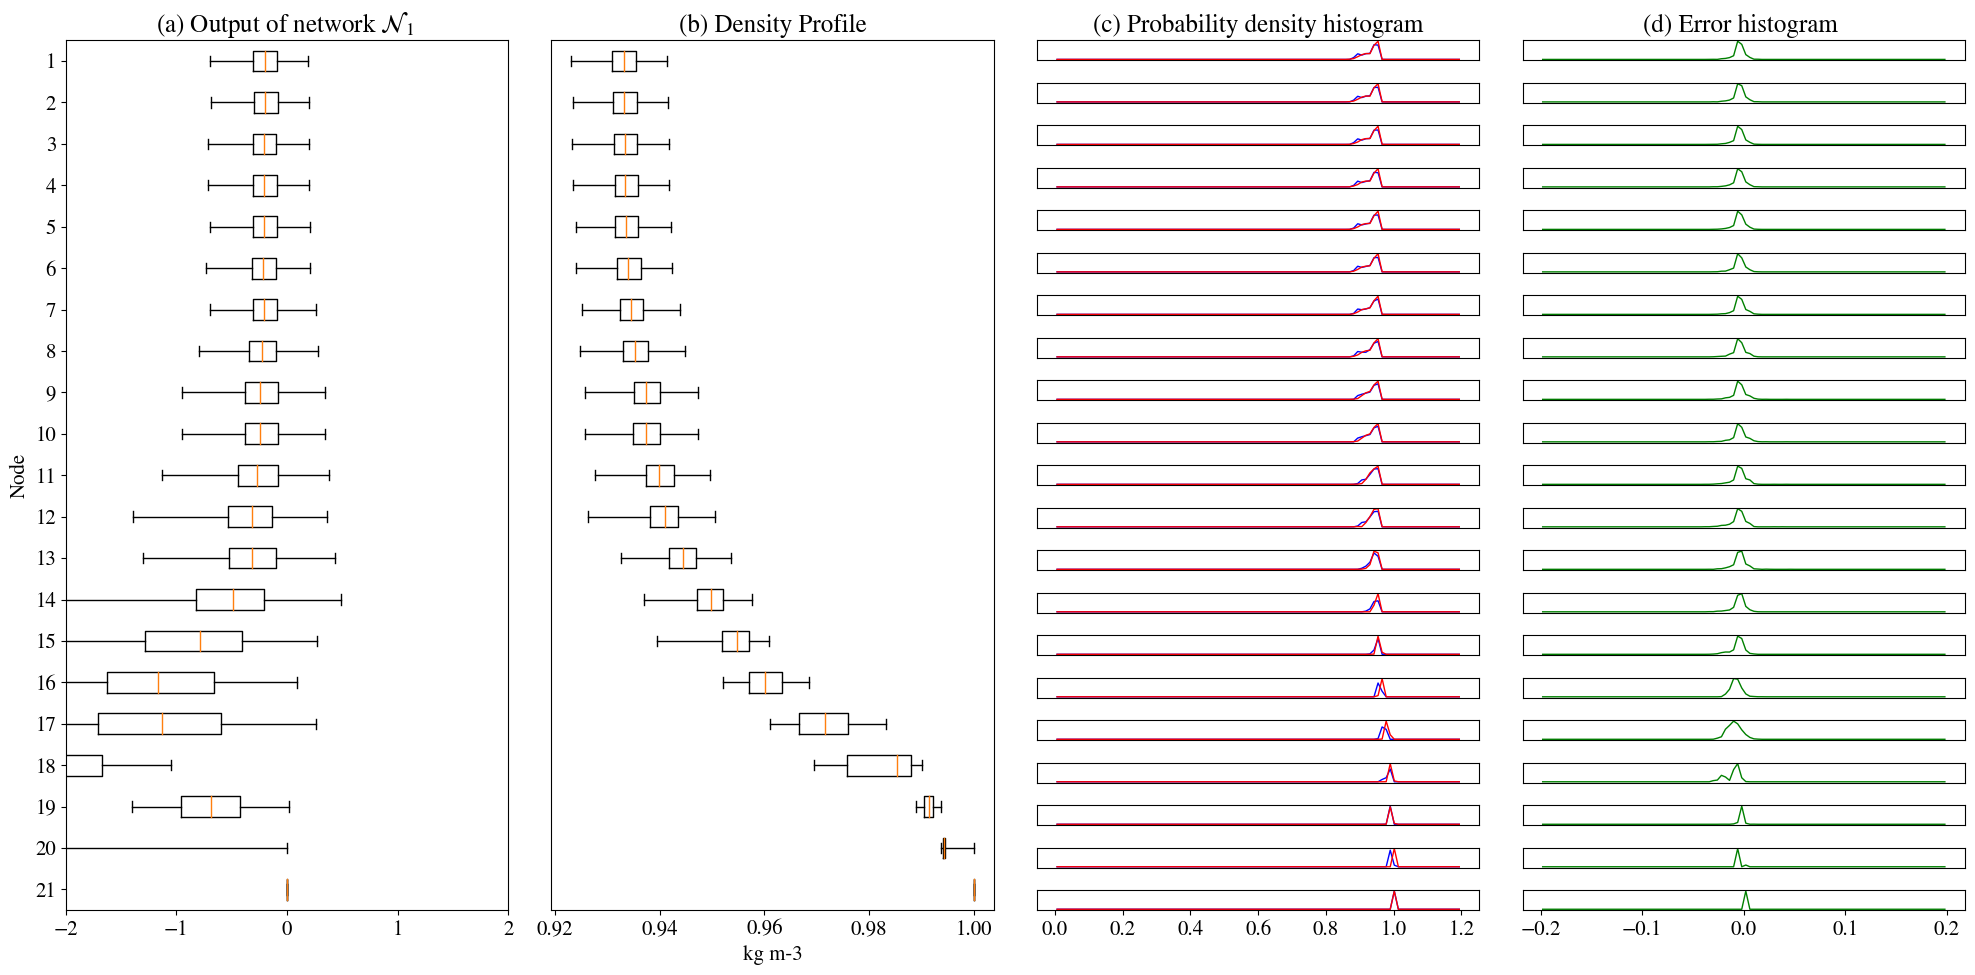

In [19]:
performance_sigma_point(
    model,
    x,
    valid_x,
    y,
    valid_y,
    k_mean,
    k_std,
    maxes,
)